# Next Character Prediction Using MLP Cont'd

In [68]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt

In [69]:
# read the dataset (names.txt)
words = open('names.txt', 'r').read().splitlines()

In [70]:
chars = sorted(list(set('.abcdefghijklmnopqrstuvwxyz')))
chartoi = {s:i for i, s in enumerate(chars)}
itochar = {i:s for s,i in chartoi.items()}

In [71]:
# build the dataset

BLOCK_SIZE = 3 # Defines the context length ie. how many characters to use to predict the next one
X, Y = [], []

for w in words:
    #print(w)
    context = [0] * BLOCK_SIZE
    for ch in w + '.':
        idx = chartoi[ch]
        X.append(context)
        Y.append(idx)
        #print(f"{"".join(itochar[c] for c in context)} --> {ch}")
        context = context[1:] + [idx] # pop and push

X = torch.tensor(X)
Y = torch.tensor(Y)

In [72]:
# split the data into training, validation, and test set

N = X.shape[0] 
n_train = int(0.8 * N)
n_val = int(0.1 * N)
# n_test is whatever is left over

indices = torch.randperm(N)

train_indices = indices[:n_train]
val_indices = indices[n_train : n_train + n_val]
test_indices = indices[n_train + n_val:]

X_train, Y_train = X[train_indices], Y[train_indices]
X_val, Y_val = X[val_indices], Y[val_indices]
X_test, Y_test = X[test_indices], Y[test_indices]

print(f"Train: {X_train.shape}, {Y_train.shape}")
print(f"Val:   {X_val.shape}, {Y_val.shape}")
print(f"Test:  {X_test.shape}, {Y_test.shape}")

Train: torch.Size([182516, 3]), torch.Size([182516])
Val:   torch.Size([22814, 3]), torch.Size([22814])
Test:  torch.Size([22816, 3]), torch.Size([22816])


In [112]:
class MLP:

    def __init__(self, block_size=3, embedding_dimensions=10, hidden_layer_size=200, output_layer_size=len(chars)):
        self.EMBEDDING_DIMENSIONS = embedding_dimensions # the dimensionality of the embedding space
        self.HIDDEN_LAYER_SIZE = hidden_layer_size # number of neurons in hidden layer
        self.OUTPUT_LAYER_SIZE = output_layer_size # number of neurons in output layer
        self.BLOCK_SIZE = block_size # context window length

        # Embedding layer + Hidden layer params
        g = torch.Generator().manual_seed(2147483647) # for reproducibility
        self.C = torch.randn((len(chars), self.EMBEDDING_DIMENSIONS), requires_grad=True, generator=g)
        self.W1 = torch.randn((self.BLOCK_SIZE * self.EMBEDDING_DIMENSIONS, self.HIDDEN_LAYER_SIZE), requires_grad=True, generator=g)
        self.W1.data *= 0.1 # scale down to keep tanh gradient non-zero

        # Batch Norm parameters
        self.bngain = torch.nn.Parameter(torch.ones((1, self.HIDDEN_LAYER_SIZE)) * 0.75)
        self.bnbias = torch.nn.Parameter(torch.zeros((1, self.HIDDEN_LAYER_SIZE)))
        self.bnmean_running = torch.zeros((1, self.HIDDEN_LAYER_SIZE), requires_grad=False)
        self.bnstd_running = torch.ones((1, self.HIDDEN_LAYER_SIZE), requires_grad=False)

        # Output layer parameters
        self.W2 = torch.randn((self.HIDDEN_LAYER_SIZE, self.OUTPUT_LAYER_SIZE), requires_grad=True, generator=g) 
        self.W2.data *= 0.01 # init small vals for even distribution
        self.b2 = torch.randn(self.OUTPUT_LAYER_SIZE, requires_grad=True, generator=g) 
        self.b2.data *= 0.0 # init to zeros
        
        self.parameters = [self.C, self.W1, self.W2, self.b2, self.bngain, self.bnbias]

    # Computes (Emb[X]*W1). Bias is skipped because this is followed by batchnorm. Doesnt apply non-linearity 
    def _compute_hidden_layer_preactivations(self, X):
        emb = self.C[X] # map inp chars to embeddings

        X1_preactivation = (emb.flatten(start_dim=1) @ self.W1) # apply linear transformation

        return X1_preactivation
    
    # Apply batch-norm + non-linear activation on the pre-activations for the hidden layer
    def _compute_hidden_layer_activations(self, X, mode='train'):
        X1_preactivation = self._compute_hidden_layer_preactivations(X)

        bnmean = X1_preactivation.mean(0, keepdim=True) if mode == 'train' else self.bnmean_running
        bnstd = X1_preactivation.std(0, keepdim=True, unbiased=False) if mode == 'train' else self.bnstd_running

        with torch.no_grad():
            if mode == 'train':
                self.bnmean_running = 0.999 * self.bnmean_running + 0.001 * bnmean
                self.bnstd_running = 0.999 * self.bnstd_running + 0.001 * bnstd

        X1_preactivation_with_batchnorm = self.bngain * (X1_preactivation - bnmean) / bnstd + self.bnbias
        
        X1 = F.tanh(X1_preactivation_with_batchnorm) # apply non-linear activation
        
        return X1
    
    # forward pass through the MLP and return logits
    def _compute_logits(self, X, mode='train'):
        X1 = self._compute_hidden_layer_activations(X, mode) # apply non-linear activation
        
        logits = (X1 @ self.W2) + self.b2 # apply linear pre-activation for output layer
        
        return logits

    # forward pass throught MLP and return next char probs
    @torch.no_grad() # disable gradient tracking as this is a post training step
    def forward(self, X):
        probs = F.softmax(self._compute_logits(X, mode='test'), dim=1) # apply softmax to output layer pre-activations
        return probs

    # do a forward pass and compute cross-entropy loss (wrt. actual labels)
    def forward_and_compute_loss(self, X, Y, mode='train'):
        loss = F.cross_entropy(self._compute_logits(X, mode), Y)
        return loss

    # zero grads all the weights in the MLP
    def zero_grad(self):
        for p in self.parameters:
            p.grad = None

    # update weights based on their calculated gradients
    def update_weights(self, learning_rate):
        for p in self.parameters:
            p.data += -learning_rate * p.grad

In [113]:
mlp = MLP()

In [114]:
# Compare exected vs actual initial loss of the network

# ideal expected initial loss:
ideal_probs = F.softmax(torch.ones((X.shape[0], len(chars))) * (1/27.0), dim=1)
ideal_loss = F.cross_entropy(ideal_probs, Y)
print(ideal_loss)

# actual initial loss:
mlp.forward_and_compute_loss(X, Y, mode='train')

tensor(3.2958)


tensor(3.2977, grad_fn=<NllLossBackward0>)

(array([ 92., 172., 149., 171., 187., 200., 203., 146., 133., 137., 116.,
        110.,  89., 157.,  90., 104., 116., 116., 139., 128., 116., 116.,
        111.,  76.,  95.,  76.,  92.,  95., 117.,  90.,  77., 137., 108.,
        101.,  64., 156., 118., 120., 118., 129.,  85., 141., 176., 188.,
        176., 169., 155., 174., 159., 110.]),
 array([-0.75559694, -0.72531379, -0.69503065, -0.66474751, -0.63446437,
        -0.60418122, -0.57389808, -0.54361494, -0.5133318 , -0.48304865,
        -0.45276551, -0.42248237, -0.39219923, -0.36191609, -0.33163294,
        -0.3013498 , -0.27106666, -0.24078352, -0.21050037, -0.18021723,
        -0.14993409, -0.11965095, -0.0893678 , -0.05908466, -0.02880152,
         0.00148162,  0.03176476,  0.06204791,  0.09233105,  0.12261419,
         0.15289733,  0.18318048,  0.21346362,  0.24374676,  0.2740299 ,
         0.30431305,  0.33459619,  0.36487933,  0.39516247,  0.42544562,
         0.45572876,  0.4860119 ,  0.51629504,  0.54657818,  0.57686133,
 

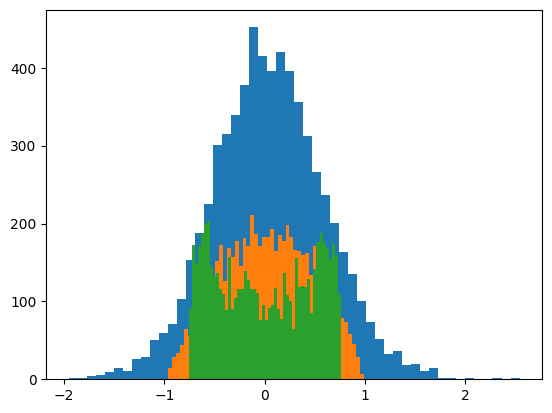

In [115]:
# plot initial distribution of pre-activation and activations of hidden layer for a random batch

ix = torch.randint(0, X_train.shape[0], (32,))
X1_preactivations = mlp._compute_hidden_layer_preactivations(X[ix])
X1 = mlp._compute_hidden_layer_activations(X[ix])
plt.hist(X1_preactivations.view(-1).tolist(), 50)
plt.hist(X1_preactivations.tanh().view(-1).tolist(), 50)
plt.hist(X1.tanh().view(-1).tolist(), 50)

Training loss at epoch 0: 3.2975237369537354
Training loss at epoch 10000: 2.244511127471924
Training loss at epoch 20000: 1.9653713703155518
Training loss at epoch 30000: 2.2602999210357666
Training loss at epoch 40000: 1.9075279235839844
Training loss at epoch 50000: 1.998073935508728
Training loss at epoch 60000: 2.320772171020508
Training loss at epoch 70000: 2.15794038772583
Training loss at epoch 80000: 2.3751108646392822
Training loss at epoch 90000: 2.1185498237609863
Training loss at epoch 100000: 2.0127854347229004
Training loss at epoch 110000: 1.9725275039672852
Training loss at epoch 120000: 2.2826099395751953
Training loss at epoch 130000: 1.9047651290893555
Training loss at epoch 140000: 2.0327682495117188
Training loss at epoch 150000: 2.364826202392578
Training loss at epoch 160000: 2.185885429382324
Training loss at epoch 170000: 2.816450834274292
Training loss at epoch 180000: 2.0517280101776123
Training loss at epoch 190000: 2.103640556335449
---Training complete---

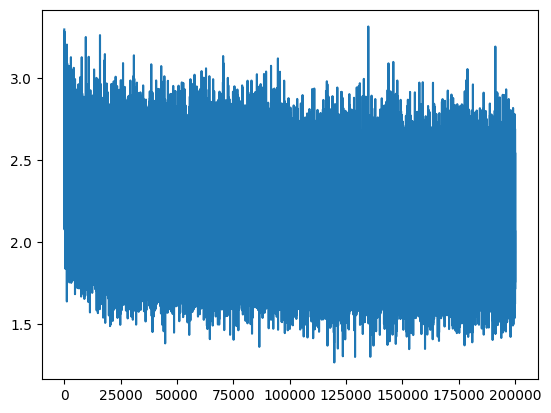

In [116]:
# train the MLP

EPOCHS = 200000
MINI_BATCH_SIZE = 32

lossi = []
stepi = []

for e in range(EPOCHS):
    # construct mini-batch
    ix = torch.randint(0, X_train.shape[0], (MINI_BATCH_SIZE,))
    
    loss = mlp.forward_and_compute_loss(X_train[ix], Y_train[ix])

    stepi.append(e)
    lossi.append(loss.item())
    
    mlp.zero_grad()
    loss.backward()

    learning_rate = 0.1 if e < 100000 else 0.01 # step learning rate decay

    mlp.update_weights(learning_rate)

    if e % 10000 == 0:
        print(f"Training loss at epoch {e}: {loss.item()}")

print(f"---Training complete---")
print(f"Final loss: {mlp.forward_and_compute_loss(X_train, Y_train, mode='train').item()}")

plt.plot(stepi, lossi)

In [117]:
@torch.no_grad() # disable gradient tracking
def split_loss(split):
    x,y = {
        "train": (X_train, Y_train),
        "val": (X_val, Y_val),
        "test": (X_test, Y_test)
    }[split]
    loss = mlp.forward_and_compute_loss(x,y, mode='test').item()
    print(split, loss)

In [118]:
split_loss("train")
split_loss("val")

train 2.066474676132202
val 2.1180620193481445


In [178]:
# generate new names using the MLP model

for i in range(1, 6):
    generated_name = "..."
    while True:
        x = torch.tensor([[chartoi[ch] for ch in generated_name[-3:]]])
        output_probs = mlp.forward(x)
        next_char_i = torch.multinomial(output_probs, num_samples=1, replacement=True).item()
        next_char = itochar[next_char_i]
        if next_char == ".":
            break
        generated_name += next_char
    print(f"Generated name {i}: {generated_name[3:]}")

Generated name 1: krisali
Generated name 2: zym
Generated name 3: kyile
Generated name 4: bresire
Generated name 5: shaidengelvi
